In [113]:
import numpy as np
import pandas as pd
import scipy
import joblib
import matplotlib.pyplot as plt
from filterpy.kalman import predict, update

## Kalman Filter Implementation with Raman and Dynamic Models

#### Design State Variable and State Covariance

In [69]:
# this is the intitial state vector with starting position and velocity
x = np.array([10.0, 4.5])
# this is the initial input to the system
u = np.array([2., 3.])
# This holds the σ^2/variance of the position and velocity
P = np.diag([100., 50.])

#### Design the Process Model

In [70]:
F = np.array([[0.358 , 0.571 ],
       [0.0241, 0.532 ]])
B = np.array([[ 0.49  ,  0.107 ],
       [-0.0825,  0.307 ]])

In [71]:
# Q is the process noise
x, P = predict(x=x, P=P, F=F, Q=0, B=B, u=u)
print('x =', x)

x = [7.4505 3.391 ]


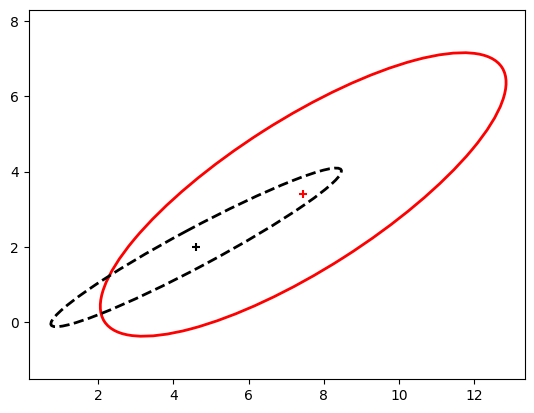

In [72]:
from filterpy.stats import plot_covariance_ellipse

plot_covariance_ellipse(x, P, edgecolor='r')
x, P = predict(x, P, F, Q=0)
plot_covariance_ellipse(x, P, edgecolor='k', ls='dashed')

#### Design the Process Noise

In [73]:
from filterpy.common import Q_discrete_white_noise
Q = Q_discrete_white_noise(dim=2, dt=1., var=2.35)

## Update Step

#### Design the Measurement Function

In [74]:
# This matrix is to convert our states to measurement space
# The function will be y = z - Hx, where z is the measurement from the raman sensor
# we will convert the VCC and glucose states to just glucose using the matrix below
# Then find the residual of the measurment - predicted
H = np.array([[0,1]])

#### Design the Measurement

In [75]:
# we only have one measurement from the raman so z is defined as
gluc = 0
z = np.array([[gluc]])
# two measurements would be defined as [z1, z2]

# Need to specify R which is a covariance matrix for the measurement noise defined 
# as an m x m matrix, with m as the number of sensors
R = np.array([[5.]])

In [76]:
from filterpy.kalman import update
z = 1.
x, P = update(x, P, z, R, H)
print('x =', x)

x = [3.78696815 1.52040273]


## Implementing the Kalman Filter

In [77]:
from filterpy.kalman import KalmanFilter
gluc_filter = KalmanFilter(dim_x=2, dim_z=1)
print('x = ', gluc_filter.x.T)
print('R = ', gluc_filter.R)
print('Q = \n', gluc_filter.Q)

x =  [[0. 0.]]
R =  [[1.]]
Q = 
 [[1. 0.]
 [0. 1.]]


In [78]:
from filterpy.kalman import KalmanFilter
from filterpy.common import Q_discrete_white_noise

def gluc_filter(x, P, R, Q=0., dt=1.0):
    """ Returns a KalmanFilter which implements a
    constant velocity model for a state [x dx].T
    """
    
    kf = KalmanFilter(dim_x=2, dim_z=1)
    kf.x = np.array([x[0], x[1]])           # location and velocity
    kf.F = np.array([[0.358, 0.571],
                     [0.0241, 0.532]])      # state transition matrix
    kf.B = np.array([[ 0.49  ,  0.107 ], 
                     [-0.0825,  0.307 ]])   # Input transition matrix
    kf.H = np.array([[0,1]])                # Measurement function
    kf.R *= R                               # measurement uncertainty
    if np.isscalar(P):
        kf.P *= P                           # covariance matrix 
    else:
        kf.P[:] = P                         # [:] makes deep copy
    if np.isscalar(Q):
        kf.Q = Q_discrete_white_noise(dim=2, dt=dt, var=Q)
    else:
        kf.Q[:] = Q
    return kf

In [80]:
x = np.array([10.0, 4.5])
# this is the initial input to the system
u = np.array([2., 3.])
# This holds the σ^2/variance of the position and velocity
P = np.diag([100., 50.])
R = np.array([[5.]])

dt = 1
kf = gluc_filter(x, P=P, R=R, Q=0.1, dt=dt)
kf

KalmanFilter object
dim_x = 2
dim_z = 1
dim_u = 0
x = [10.   4.5]
P = [[100.   0.]
     [  0.  50.]]
x_prior = [[0. 0.]].T
P_prior = [[1. 0.]
           [0. 1.]]
x_post = [[0. 0.]].T
P_post = [[1. 0.]
          [0. 1.]]
F = [[0.358  0.571 ]
     [0.0241 0.532 ]]
Q = [[0.025 0.05 ]
     [0.05  0.1  ]]
R = [[5.]]
H = [[0 1]]
K = [[0. 0.]].T
y = [[0.]]
S = [[0.]]
SI = [[0.]]
M = [[0.]]
B = [[ 0.49    0.107 ]
     [-0.0825  0.307 ]]
z = [[None]]
log-likelihood = -708.3964185322641
likelihood = 2.2250738585072014e-308
mahalanobis = 0.0
alpha = 1.0
inv = <function inv at 0x000001964E1BBE20>

#### Clean data for Kalman Filter

In [124]:
dcs_data = pd.read_excel(r"C:\Users\zah48132\OneDrive - GSK\Documents\GitHub\state-space-model\data\raw\DCS-Kalman-Filter-Data.xlsx")
scaler_train = joblib.load(r"C:\Users\zah48132\OneDrive - GSK\Documents\GitHub\state-space-model\scaler_train.scale")

In [125]:
pd.DataFrame(index=scaler_train.feature_names_in_, data=scaler_train.scale_)

,0
Glucose Added (mL),0.059172
F30 Feed Amount (mL),0.016100
TCC,0.023093
Daily_Feed_Normalized,22.125556
Gluc,0.144300
IGG,0.000180
Daily_Glucose_Normalized,68.085185
VCC,0.015565
Ammonium,0.035063
Lact,0.120192


### Running the Kalman Filter

In [135]:
x = np.array([10.0, 4.5])
F = np.array([[0.358, 0.571],
            [0.0241, 0.532]])
B = np.array([[ 0.49  ,  0.107 ], 
            [-0.0825,  0.307 ]])
H = np.array([[0,1]])
P = np.diag([100., 50.])
R = np.array([[5.]])

In [136]:
from filterpy.kalman import KalmanFilter
from filterpy.common import Q_discrete_white_noise

def gluc_filter(x, F, B, H, P, R, Q=0., dt=1.0):
    """ Returns a KalmanFilter which implements a
    constant velocity model for a state [x dx].T
    """
    
    kf = KalmanFilter(dim_x=2, dim_z=1)
    kf.x = x                # location and velocity
    kf.F = F                # state transition matrix
    kf.B = B                # Input transition matrix
    kf.H = H                # Measurement function
    kf.R *= R               # measurement uncertainty
    if np.isscalar(P):
        kf.P *= P           # covariance matrix 
    else:
        kf.P[:] = P         # [:] makes deep copy
    if np.isscalar(Q):
        kf.Q = Q_discrete_white_noise(dim=2, dt=dt, var=Q)
    else:
        kf.Q[:] = Q
    return kf

In [142]:
def run( u, kf, dt, zs, do_plot=True, **kwargs):
    """
    track is the actual glucose measurement, zs are the 
    corresponding measurements.
    """

    # Simulate dog if no data provided. 
    if zs is None:
        pass
        # track, zs = compute_dog_data(R, Q, count)

    # run the kalman filter and store the results
    xs, cov = [], []
    for count, z in enumerate(zs):
        kf.predict(u[count])
        kf.update(z)
        xs.append(kf.x)
        cov.append(kf.P)

    xs, cov = np.array(xs), np.array(cov)
    x_plot = np.arange(0, len(zs), dt)
    if do_plot:
        plt.plot(x_plot, xs, "ro", markersize=1)
        plt.plot(x_plot, zs, "b-")
    return xs, cov

In [144]:
kf = gluc_filter(x, F, B, H, P, R, Q=0., dt=1.0)

Ms, Ps = run(
    kf=kf,
    dt=1,
    u=np.array(dcs_data[["Feed_Normalized","Glucose_feed_Normalized"]]),
    zs=np.array(dcs_data["Glucose_Normalized"]),
    count=len(dcs_data["Glucose_Normalized"]),
)

IndexError: index 1123 is out of bounds for axis 0 with size 1123